# Modelling PEMFC polarization curves
The goal of this example script is to model beginning-of-life polarization curves obtained for four different operating pressures between 1.5 and 2.5 bara with a 1 kW EH-31  stack from EH Group, dated 2022. It is the same data used for validation of a 1D model proposed by Gass *et al.* [1]. The stack has 5 cells with a 0.85 cm<sup>2</sup> active area. The cell operates at 347.15 K, cathode and anode stoichiometries of 2.0 and 1.2 and relative humidities of 60 % and 40 %, respectively.

[1]  Gass, R., Li, Z., Outbib, R., Jemei, S. & Hissel, D. An advanced 1D physics-based model for PEM hydrogen fuel cells with enhanced overvoltage prediction. Int. J. Hydrogen Energy 97, 1108–1125 (2025).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
import marapendi as mrpd


## Importing experimental data 
We start by importing the experimental data from .csv files in the `data/gass_et_al_2024` folder. Each .csv file contains experimental data for one polarization curve, at a given pressure.  

In [2]:


test_pressure_list = (1.5,2,2.25,2.5)

exp_data = {p: pd.read_csv(f'../data/gass_et_al_2024/gass_et_al_data_{p*1e3:.0f}.csv',skiprows=1).iloc[::4] 
            for p in test_pressure_list}

We then plot the experimental polarization curves.

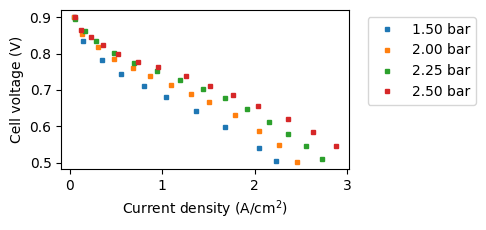

In [3]:
fig, ax = plt.subplots(figsize=(5,2.4))
for k, p in enumerate(test_pressure_list): 
    i_exp = exp_data[p]['i'].values
    U_exp = exp_data[p]['U'].values
    l2, = ax.plot(i_exp, U_exp, 'sC{}'.format(k), label='{:.2f} bar'.format(p), markersize=2.5)
leg1 = ax.legend(bbox_to_anchor=(1.04,1), loc='upper left') 
ax.set_xlabel('Current density (A/cm$^2$)')
ax.set_ylabel('Cell voltage (V)')
fig.tight_layout()

## Preparing the simulations

We need to define the `OperatingConditions` objects for each case. These are holders for operating conditions on each side of the fuel cell. Each variable must be defined as a scalar or a vector, provided broadcasting rules can be applied. Here we define a function that takes as inputs a vector for current density values (for which the cell voltages will be returned), the stack temperature and pressure. 

We consider that the stoichiometry are held for current densities above 0.2 A/cm<sup>2</sup>, even though we don't have information about the true experimental conditions regarding this. 

In [4]:
stack_temperature = 347.15 

current_density = {p: 1e4*exp_data[p]['i'].values for p in test_pressure_list}

cathode_conditions = {p: mrpd.OperatingConditions(
        inlet_temperature = stack_temperature,
        inlet_relative_humidity=.6,
        outlet_pressure=1e5 * p,
        dry_o2_mole_fraction=0.21,
        dry_h2_mole_fraction=0,
        stoichiometry=np.maximum(2., 2 * 0.1e4 / (current_density[p]+1e-4))
    ) for p in test_pressure_list}

anode_conditions = {p: mrpd.OperatingConditions(
    inlet_temperature = stack_temperature,
    inlet_relative_humidity=0.4,
    dry_h2_mole_fraction=1, 
    dry_o2_mole_fraction=0,
    outlet_pressure=1e5 * p,
    stoichiometry=np.maximum(1.2, 1.2 * 0.1e4 / (current_density[p]+1e-4))
) for p in test_pressure_list}

In order to be able to estimate a certain number of unknown parameters, we create a function that takes as input a dictionary of parameter values `params` and returns a corresponding `FuelCell` object.

In [5]:
def create_fuel_cell(params):
    memb = mrpd.Membrane(
            equivalent_weight=1100,
            dry_density=1980, 
            dry_thickness=params['memb-thickness'],
            conductivity_exp=params['memb-cond-exp'],
            conductivity_correction=params['memb-cond-correction'],
            h2_permeation_model=mrpd.HydrogenPermeationModel(), 
            water_balance_model=mrpd.MembraneWaterBalanceModel(
                reference_water_chemical_diffusion_coefficient=params['memb-water-diff'],
                reference_absorption_coefficient=params['memb-abs-constant'])
    )
    
    orr_kinetics = mrpd.ElectrochemicalReaction(
                    reference_exchange_current_density=2.54e-4, 
                    reaction_order=0.54, 
                    activation_energy=67e6, 
                    reference_activity=1.01325e5,
                    reference_temperature=353.15,
                    number_of_electrons=2,
                    charge_transfer_coeff=0.5
    ) 
    
    gdl = mrpd.PorousLayer(
                thickness=200e-6,
                contact_angle=120.,
                effective_gas_diffusion_ratio=params['gdl-eff-diff-ratio'],
                absolute_permeability=params['gdl-abs-perm'],
                thermal_conductivity=params['gdl-thermal-cond'] 
    )

    gfc = {side: mrpd.GasFlowChannel(
                height=params['ch-height'], 
                width=0.45e-3, 
                n_parallel=50, 
                length=9.67/50,
                reactant='o2' if side == 'ca' else 'h2',
                transport_resistance_model = mrpd.ChannelGasResistanceModel(
                    A_ch=params['A_ch'], B_ch=params['B_ch']
                )
            ) for side in ['an', 'ca']
    } 
    
    liq_model = mrpd.DarcyLiquidTransportModel(
                dry_wet_transition_parameter=params['wet-transition']
    )

    fc = mrpd.FuelCell(
        electrical_resistance=params['elec-resistance'],
        cell_area = 85e-4, cell_number = 5, 
        ca = mrpd.FuelCellSide(
            cl=mrpd.CatalystLayer(
                ecsa=params['ecsa'], 
                platinum_loading=params['pt-loading'], 
                ionomer=mrpd.CatalystLayerIonomerModel(),
                catalyst_platinum_weight_percent=0.4,
                ionomer_to_carbon_ratio=params['ic-ratio'],
                pore_diameter=30e-9, omega_PtO=0, 
                carbon_agglomerate_radius=25e-9,
                thickness=2.7e-6*(params['pt-loading']*1e3),
                absolute_permeability=1e-13, contact_angle=95.,
                thermal_conductivity=0.25,
                reaction=orr_kinetics
                
            ),
            gdl=gdl, has_mpl=False, ch= gfc['ca'],
            liq_transport_model=liq_model,
            thermal_contact_resistance=5e-4,
        ),
        an = mrpd.FuelCellSide(
            cl=mrpd.CatalystLayer(
                ecsa=params['ecsa'], 
                platinum_loading=1e-3, 
                catalyst_platinum_weight_percent=0.4,
                ionomer_to_carbon_ratio=params['ic-ratio'],
                pore_diameter=30e-9,
                carbon_agglomerate_radius=25e-9,
                thickness=2.7e-6,
                absolute_permeability=1e-13,
                contact_angle=95.,
                thermal_conductivity=0.25,              
            ),
            has_mpl=False, gdl=gdl, ch=gfc['an'],
            liq_transport_model=liq_model,
            thermal_contact_resistance=5e-4,
        ),
        membrane = memb
    )
    
    return fc

We then need a function to return the simulated values of the experimetal data for a given set of parameters, defined in the dictionary `params`. This is the function `h`. In the notation used in control engineering for non-linear dynamic systems: 
$$\dot x = f(x,u)$$
$$y = h(x,u)$$
where $x$ is the vector of states of the system, $u$ the vector of inputs and $y$ the vector of measureable outputs. For a steady-state problem, $h$ is a function of the system inputs $u$ only (given a set of model parameters $p$). 
$$y = h(u|p)$$


In [6]:
train_pressure_list = (1.5,2,2.5)


def h(params, pressure_list=train_pressure_list): 
    fuel_cell = create_fuel_cell(params)
    return np.concatenate(
         [fuel_cell.compute_ui_curve(current_density[p], stack_temperature, 
                                      cathode_conditions[p], anode_conditions[p])
          for p in pressure_list]
    )
    

The function `h` and a set of parameters define a model, for which we can estimate the parameters. We need to define this model as a `ParameterEstimationSteadyState` object. 

In [7]:
initial_parameters = {
    # CL parameters 
    'ecsa': 70e3, 'pt-loading': 4e-3, 'ic-ratio': 1,           
    # Electric resistance 
    'elec-resistance': 30e-7, 
    # Channel resistance parameters 
    'A_ch': 1, 'B_ch': 1,'ch-height': 0.2e-3,
    # GDL parameters 
    'gdl-eff-diff-ratio': 0.3, 'gdl-thermal-cond': 0.2, 'gdl-abs-perm':1.e-13,
    # Membrane parameters
    'memb-thickness': 8e-6, 'memb-water-diff': 4.3e-10, 'memb-abs-constant': 1e-5,
    'memb-cond-exp':1.5, 'memb-cond-correction': 1,
    # Liquid water model power-law exponent
    'wet-transition': 0.25, 
}

model = mrpd.ParameterEstimationSteadyState(h, initial_parameters)


## Estimating parameters

We first need to build a vector of measured outputs from the experimental cell voltages for each pressure condition. We do this for both test and train sets.

In [8]:
train_exp_voltage_list = np.concatenate(
         [exp_data[p]['U'] for p in train_pressure_list]
    )

test_exp_voltage_list = np.concatenate(
         [exp_data[p]['U'] for p in test_pressure_list]
    )

Then we define the set of unknown parameters. Each one is defined as a tuple with its key in the `params` dictionary, a tuple of lower and upper bounds, a boolean indicating if the parameter should be normalized in a linear (True) or log (False) scale and a label for the parameter to be used as a label in plots. 

In [9]:
model.set_unknown_params(
        [
        ('elec-resistance', (20e-7, 60e-7), True, '$r_{elec}$'),
        ('memb-thickness',(8e-6,15e-6), True, r'$t_{memb}$'),
        ('memb-cond-correction',(.1,5), True, r'$\xi_{\sigma}^{memb}$'),
        ('memb-cond-exp',(1,2), True, '$n_{\sigma}^{memb}$'),
        ('ecsa', (45e3,90e3), True, 'ECSA'),
        ('pt-loading', (0.3e-2, 0.5e-2), True, 'Pt loading'),
        ('ic-ratio', (0.8,1.2), True, 'IC ratio'),
        ('A_ch', (0.2, 2), True, '$A_{ch}$'),
        ('B_ch', (0.2, 2), True, '$B_{ch}$'),
        ('ch-height', (0.15e-3, 0.5e-3), True, '$h_{ch}$'),
        ('gdl-eff-diff-ratio', (0.2,0.5), True, '$D^{GDL}_{eff}/D$'), 
        ('gdl-abs-perm', (1e-14,1e-11), False, '$K_{abs}^{GDL}$'),
        ('gdl-thermal-cond', (0.2,2), True, '$k_{GDL}$'),
        ('wet-transition', (0.2, .5), True, '$n_{s}$'),
        # ('memb-water-diff', (1e-10, 10e-10), True, '$D_{\lambda}$'),
        ('memb-abs-constant', (1e-6, 1e-4), False, '$k_{abs}$'),
        ]
    )


### Sensitivity analysis
Once the list of unkwnon parameters is defined, we can apply the global sensitivity analysis proposed by Goshtasbi et al. [2,3]. The sensitivity matrix is, for a given set of parameter values, defined as: 

$$S_{ij} = \frac{\partial y_i}{\partial \theta_j}$$

where $y_i$ is the $i$-th output and $\theta_j$ the $j$-th parameter. The sensitivity vector for the $i$-th parameter is given by: 

$$\mathbf{s}_i = \begin{pmatrix} \frac{\partial y_i}{\partial \theta_1} & \frac{\partial y_i}{\partial \theta_2} & ... & \frac{\partial y_i}{\partial \theta_1} \end{pmatrix}$$

We sample $n_k$ samples in the parameter space, such that we have $n_k$ sensitivity matrices, and $n_k$ sensitivity vectors for each parameter. We can then define the median sensitivity vector: 

$$\bar{\mathbf{s}}_i = \mathrm{med}_k \| \mathbf{s}_i^k \|_2 $$

and the colinearity index: 

$$\psi_{ij}^k = \cos(\phi_{ij}^k) = \frac{\lvert \mathbf{s}_i^k{}^\mathrm{T} \mathbf{s}_j^k \rvert}{\|\mathbf{s}_i^k\|_2 \|\mathbf{s}_j^k\|_2}$$

According to Goshtasbi et al. [2], this index must be < 0.9 to allow for a proprer identifiability of a couple of parameters. They also define a threshold of $\bar{\mathbf{s}}_i > 0.1$ for identifiability. 


[2] Goshtasbi, A., Chen, J., Waldecker, J. R., Hirano, S. & Ersal, T. Effective parameterization of PEM fuel cell models—part I: Sensitivity analysis and parameter identifiability. J. Electrochem. Soc. 167, 044504 (2020).

[3] Goshtasbi, A., Chen, J., Waldecker, J. R., Hirano, S. & Ersal, T. Effective parameterization of PEM fuel cell models—part II: Robust parameter subset selection, robust optimal experimental design, and multi-step parameter identification algorithm. J. Electrochem. Soc. 167, 044505 (2020).

In [10]:

cosPhi_med_ij, norm_s_i, S_med, S_std, S_med_i, S_std_i, S_n, n_valid = model.compute_global_sensitivity(t=0, m=6,  
                                                                                                         check_samples=True,
                                                                                                         y_exp=train_exp_voltage_list, 
                                                                                                         res_limit=0.01)


We can check the global sensitivity. 

Number of valid samples: 40


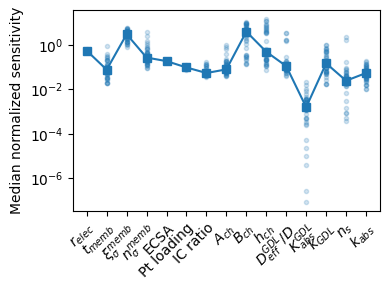

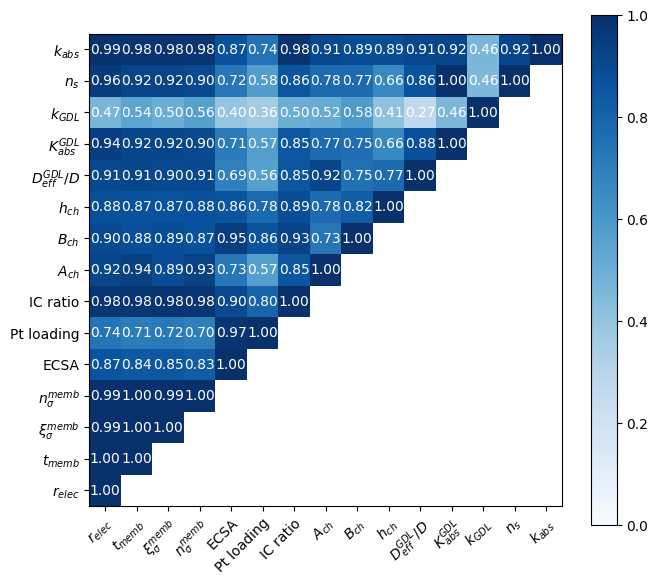

In [11]:
print('Number of valid samples: {:d}'.format(n_valid))
fig1, ax1 = model.plot_global_sensitivity(xlabel_angle=45) 
fig2, ax2 = model.plot_colinearity_map(xlabel_angle=45, cmap='Blues',figsize=(7,6))

plt.show()

We remove the parameters which are highly colinear with others. For each couple for which the colinearity coefficient was higher than 0.9, we removed the parameter with lower sensitivity. That includes: $r_{elec}$, ECSA, $L_{Pt}$, IC ratio, $t_{memb}$, $k_{abs}$, $n_{\sigma}^{memb}$,$K_{abs}^{GDL}$ and $n_{s}$. We perform once more the sensitivity analysis with the reduced set of parameters to confirm that we have colinearity coefficients lower than $\approx$ 0.9. 

Number of valid samples: 61


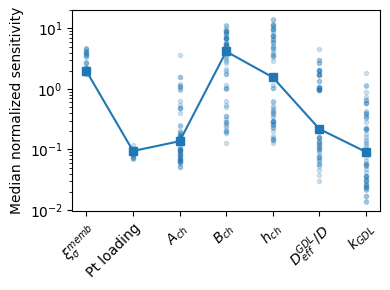

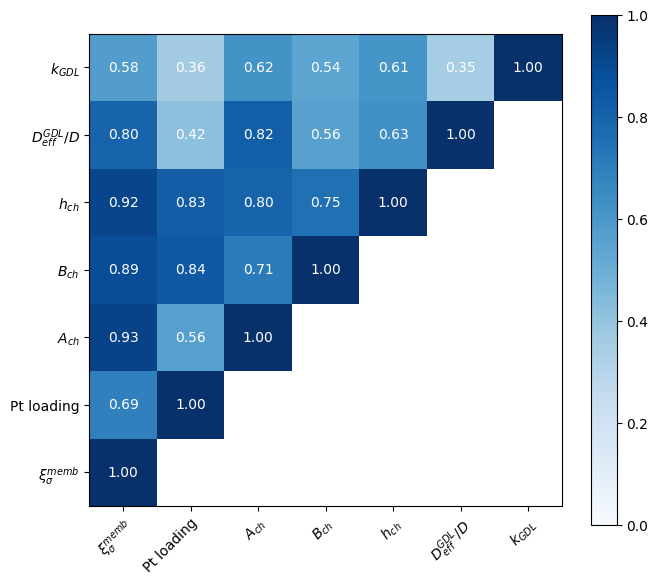

In [20]:
model.p.update({
    'memb-thickness': 8e-6,
    'wet_transition': 0.2,
    'pt-loading': 0.4e-2,
    'ECSA': 80e3,
    'memb-cond-exp': 1.5,
    'elec-resistance': 20e-7,
    'memb-abs-constant': 1e-5,
    'gdl-thermal-cond': 0.2,
    'ic-ratio': 1,
})

model.set_unknown_params(
        [
        #('elec-resistance', (20e-7, 60e-7), True, '$r_{elec}$'),
        #('memb-thickness',(8e-6,15e-6), True, r'$t_{memb}$'),
        ('memb-cond-correction',(.1,5), True, r'$\xi_{\sigma}^{memb}$'),
        #('memb-cond-exp',(1,2), True, '$n_{\sigma}^{memb}$'),
        #('ecsa', (45e3,90e3), True, 'ECSA'),
        ('pt-loading', (0.3e-2, 0.5e-2), True, 'Pt loading'),
        #('ic-ratio', (0.8,1.2), True, 'IC ratio'),
        ('A_ch', (0.2, 2), True, '$A_{ch}$'),
        ('B_ch', (0.2, 2), True, '$B_{ch}$'),
        ('ch-height', (0.15e-3, 0.5e-3), True, '$h_{ch}$'),
        ('gdl-eff-diff-ratio', (0.2,0.5), True, '$D^{GDL}_{eff}/D$'), 
        #('gdl-abs-perm', (1e-14,1e-12), True, '$K_{abs}^{GDL}$'),
        ('gdl-thermal-cond', (0.2,2), True, '$k_{GDL}$'),
        #('wet-transition', (0.2, .5), True, '$n_{s}$'),
        # ('memb-water-diff', (1e-10, 10e-10), True, '$D_{\lambda}$'),
        #('memb-abs-constant', (1e-6, 1e-4), False, '$k_{abs}$'),
        ]
    )

cosPhi_med_ij, norm_s_i, S_med, S_std, S_med_i, S_std_i, S_n, n_valid = model.compute_global_sensitivity(t=0, m=7,  
                                                                                                         check_samples=True,
                                                                                                         y_exp=train_exp_voltage_list, 
                                                                                                         res_limit=0.01)
print('Number of valid samples: {:d}'.format(n_valid))
fig1, ax1 = model.plot_global_sensitivity(xlabel_angle=45) 
fig2, ax2 = model.plot_colinearity_map(xlabel_angle=45, cmap='Blues',figsize=(7,6))

plt.show()

### Least squares optimization 
And finally we can run parameter estimation, which uses a differential evolution algorithm. 

In [21]:
sol, p_est = model.estimate(train_exp_voltage_list, t=0, print_iterations=True, popsize=40, ftol=1e-5, penalty_threshold=0)

differential_evolution step 1: f(x)= 0.00028630960546171543
------------------------------
RMSE : 16.9 mV
memb-cond-correction (0.1, 5) 2.61e+00
pt-loading (0.003, 0.005) 4.88e-03
A_ch (0.2, 2) 5.51e-01
B_ch (0.2, 2) 4.36e-01
ch-height (0.00015, 0.0005) 1.59e-04
gdl-eff-diff-ratio (0.2, 0.5) 4.50e-01
gdl-thermal-cond (0.2, 2) 2.94e-01
------------------------------
differential_evolution step 2: f(x)= 0.00014514689552974598
------------------------------
RMSE : 12.0 mV
memb-cond-correction (0.1, 5) 1.17e+00
pt-loading (0.003, 0.005) 3.91e-03
A_ch (0.2, 2) 5.49e-01
B_ch (0.2, 2) 4.78e-01
ch-height (0.00015, 0.0005) 2.89e-04
gdl-eff-diff-ratio (0.2, 0.5) 3.84e-01
gdl-thermal-cond (0.2, 2) 2.31e-01
------------------------------
differential_evolution step 3: f(x)= 0.00014514689552974598
------------------------------
RMSE : 12.0 mV
memb-cond-correction (0.1, 5) 1.17e+00
pt-loading (0.003, 0.005) 3.91e-03
A_ch (0.2, 2) 5.49e-01
B_ch (0.2, 2) 4.78e-01
ch-height (0.00015, 0.0005) 2.89e-04
g

Once we have the results, we can update the model dictionary of parameter values. 

In [22]:
model.p.update({param: v for param, v in zip(model.p_i_name, p_est)})


## Checking the results
We can start by checking the values of the estimated parameters. 

In [23]:
pd.Series(data={param: v for param, v in zip(model.p_i_name, p_est)})

memb-cond-correction    1.677616
pt-loading              0.004256
A_ch                    0.448649
B_ch                    0.581255
ch-height               0.000210
gdl-eff-diff-ratio      0.497606
gdl-thermal-cond        0.224311
dtype: float64

We then plot the comparison between experimental and simulation results for the test dataset (all pressures). We also calculate RMSE for each polarization curve. 

RMSE for 1.5 bara: 11 mV
RMSE for 2.0 bara: 12 mV
RMSE for 2.2 bara: 8 mV
RMSE for 2.5 bara: 6 mV


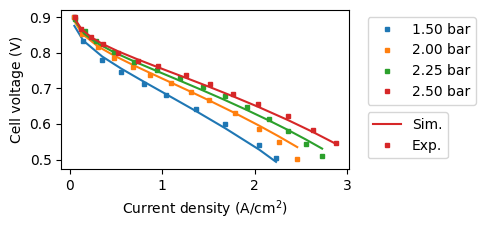

In [24]:
fuel_cell = create_fuel_cell(model.p)
fig, ax = plt.subplots(figsize=(5,2.4))
fig.set_tight_layout(True)
RMSE_avg = 0
for k, p in enumerate(test_pressure_list): 
    i_exp = exp_data[p]['i'].values
    U_exp = exp_data[p]['U'].values
    U_sim = fuel_cell.compute_ui_curve(current_density[p], stack_temperature, 
                                cathode_conditions[p], anode_conditions[p])
    res = U_exp - U_sim
    RMSE = np.sqrt(np.dot(res, res) / len(res)) * 1000
    print('RMSE for {:.1f} bara: {:.0f} mV'.format(p, RMSE))
    RMSE_avg += RMSE
    l1, = ax.plot(i_exp, U_sim, '-C{}'.format(k))
    l2, = ax.plot(i_exp, U_exp, 'sC{}'.format(k), label='{:.2f} bar'.format(p), markersize=2.5)
leg2 = ax.legend(handles=[l1,l2], labels=['Sim.', 'Exp.'], bbox_to_anchor=(1.04,0.4), loc='upper left') 
leg1 = ax.legend(bbox_to_anchor=(1.04,1), loc='upper left') 
ax.add_artist(leg2)
ax.set_xlabel('Current density (A/cm$^2$)')
ax.set_ylabel('Cell voltage (V)')
fig.tight_layout()

We can also calculate the relative errors. We can see that they remain below 5 % except for the highest current density at 2 bara. Further, they are below 3 

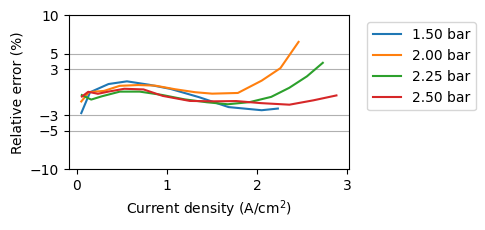

In [25]:
fuel_cell = create_fuel_cell(model.p)
fig, ax = plt.subplots(figsize=(5,2.4))
fig.set_tight_layout(True)
RMSE_avg = 0
for k, p in enumerate(test_pressure_list): 
    i_exp = exp_data[p]['i'].values
    U_exp = exp_data[p]['U'].values
    U_sim = fuel_cell.compute_ui_curve(current_density[p], stack_temperature, 
                            cathode_conditions[p], anode_conditions[p])
    ax.plot(i_exp, 100*(U_sim-U_exp)/U_exp, '-C{}'.format(k), label='{:.2f} bar'.format(p))
leg1 = ax.legend(bbox_to_anchor=(1.04,1), loc='upper left') 
ax.set_xlabel('Current density (A/cm$^2$)')
ax.set_ylim([-6,6])
ax.set_yticks([-10, -5,-3,3,5,10])
ax.grid(axis='y')
ax.set_ylabel('Relative error (%)')
fig.tight_layout()


Same for the power density. 

RMSE for 1.5 bara: 13 W/cm2
RMSE for 2.0 bara: 26 W/cm2
RMSE for 2.2 bara: 18 W/cm2
RMSE for 2.5 bara: 11 W/cm2


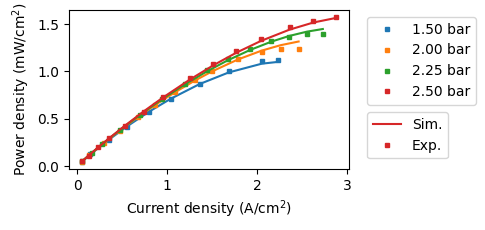

In [26]:
fuel_cell = create_fuel_cell(model.p)
fig, ax = plt.subplots(figsize=(5,2.4))
fig.set_tight_layout(True)
RMSE_avg = 0
for k, p in enumerate(test_pressure_list): 
    i_exp = exp_data[p]['i'].values
    U_exp = exp_data[p]['U'].values
    U_sim = fuel_cell.compute_ui_curve(current_density[p], stack_temperature, 
                                cathode_conditions[p], anode_conditions[p])
    res = (U_exp - U_sim) * i_exp
    RMSE = np.sqrt(np.dot(res, res) / len(res)) * 1000
    print('RMSE for {:.1f} bara: {:.0f} W/cm2'.format(p, RMSE))
    RMSE_avg += RMSE
    l1, = ax.plot(i_exp, U_sim * i_exp, '-C{}'.format(k))
    l2, = ax.plot(i_exp, U_exp * i_exp, 'sC{}'.format(k), label='{:.2f} bar'.format(p), markersize=2.5)
leg2 = ax.legend(handles=[l1,l2], labels=['Sim.', 'Exp.'], bbox_to_anchor=(1.04,0.4), loc='upper left') 
leg1 = ax.legend(bbox_to_anchor=(1.04,1), loc='upper left') 
ax.add_artist(leg2)
ax.set_xlabel('Current density (A/cm$^2$)')
ax.set_ylabel('Power density (mW/cm$^2$)')
fig.tight_layout()

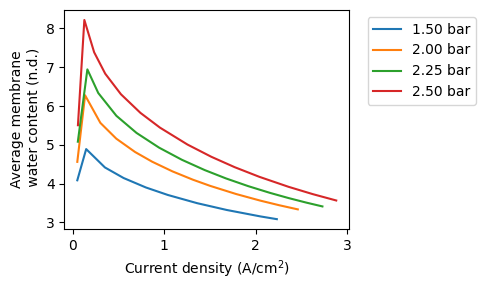

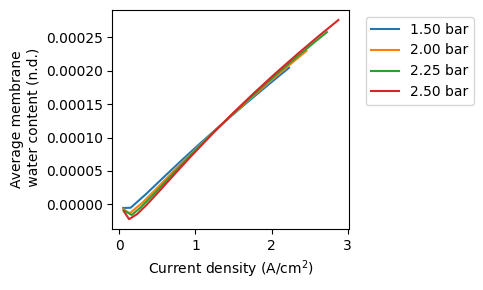

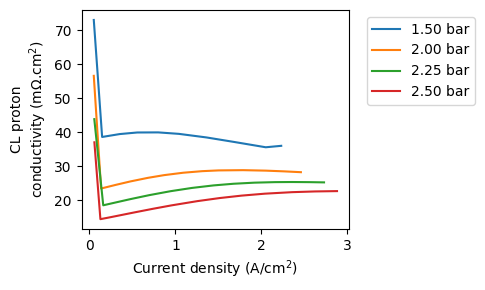

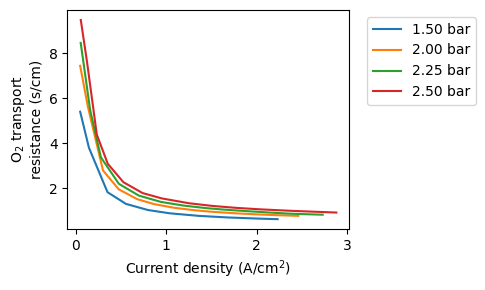

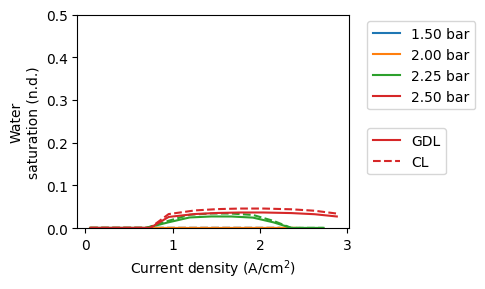

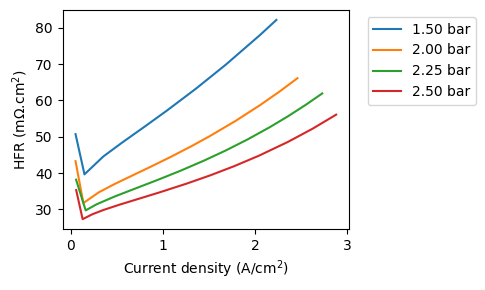

In [28]:

fuel_cell = create_fuel_cell(model.p)
fig, ax = plt.subplots(figsize=(5,3))
fig.set_tight_layout(True)
for k, p in enumerate(test_pressure_list): 
   U_sim = fuel_cell.compute_ui_curve(current_density[p], stack_temperature, 
                              cathode_conditions[p], anode_conditions[p])
   # ax.plot(fuel_cell.current_density/1e4, fuel_cell.ca.equiv_water_content, '.C{}'.format(k),)
   ax.plot(fuel_cell.current_density/1e4, fuel_cell.membrane.water_content, label='{:.2f} bar'.format(p, RMSE))
   # ax.plot(fuel_cell.current_density/1e4, fuel_cell.membrane.water_balance_model.water_content_profile[-1,:], '--C{}'.format(k), label='{:.2f} bar'.format(p, RMSE))
   # ax.plot(fuel_cell.current_density/1e4, fuel_cell.membrane.water_balance_model.water_content_profile[0,:], '-.C{}'.format(k), label='{:.2f} bar'.format(p, RMSE))
#leg2 = ax.legend(handles=[l1,l2], labels=['Sim.', 'Exp.'], bbox_to_anchor=(1.04,0.5), loc='upper left') 
leg1 = ax.legend(bbox_to_anchor=(1.04,1), loc='upper left') 
ax.set_xlabel('Current density (A/cm$^2$)')
ax.set_ylabel('Average membrane\n water content (n.d.)')
fig.tight_layout()

fuel_cell = create_fuel_cell(model.p)
fig, ax = plt.subplots(figsize=(5,3))
fig.set_tight_layout(True)
for k, p in enumerate(test_pressure_list): 
   U_sim = fuel_cell.compute_ui_curve(current_density[p], stack_temperature, 
                              cathode_conditions[p], anode_conditions[p])
   ax.plot(fuel_cell.current_density/1e4, fuel_cell.membrane.water_balance_model.cathode_flux(fuel_cell) + fuel_cell.h2o_production, label='{:.2f} bar'.format(p, RMSE))
  #leg2 = ax.legend(handles=[l1,l2], labels=['Sim.', 'Exp.'], bbox_to_anchor=(1.04,0.5), loc='upper left') 
leg1 = ax.legend(bbox_to_anchor=(1.04,1), loc='upper left') 
ax.set_xlabel('Current density (A/cm$^2$)')
ax.set_ylabel('Average membrane\n water content (n.d.)')
fig.tight_layout()

fig, ax = plt.subplots(figsize=(5,3))
fig.set_tight_layout(True)
for k, p in enumerate(test_pressure_list): 
   U_sim = fuel_cell.compute_ui_curve(current_density[p], stack_temperature, 
                              cathode_conditions[p], anode_conditions[p])
   ax.plot(fuel_cell.current_density/1e4, 1e7*fuel_cell.ca.cl.proton_resistance, label='{:.2f} bar'.format(p, RMSE))
#leg2 = ax.legend(handles=[l1,l2], labels=['Sim.', 'Exp.'], bbox_to_anchor=(1.04,0.5), loc='upper left') 
leg1 = ax.legend(bbox_to_anchor=(1.04,1), loc='upper left') 
ax.set_xlabel('Current density (A/cm$^2$)')
ax.set_ylabel('CL proton\nconductivity (m$\Omega$.cm$^2$)')
fig.tight_layout()

fig, ax = plt.subplots(figsize=(5,3))
fig.set_tight_layout(True)
for k, p in enumerate(test_pressure_list): 
   U_sim = fuel_cell.compute_ui_curve(current_density[p], stack_temperature, 
                              cathode_conditions[p], anode_conditions[p])
   ax.plot(fuel_cell.current_density/1e4, 1e-2*fuel_cell.ca.gas_transport_resistance('o2', fuel_cell.ca.cl.ionomer_water_content), label='{:.2f} bar'.format(p, RMSE))
#leg2 = ax.legend(handles=[l1,l2], labels=['Sim.', 'Exp.'], bbox_to_anchor=(1.04,0.5), loc='upper left') 
leg1 = ax.legend(bbox_to_anchor=(1.04,1), loc='upper left') 
ax.set_xlabel('Current density (A/cm$^2$)')
ax.set_ylabel('O$_2$ transport\nresistance (s/cm)')
fig.tight_layout()

fig, ax = plt.subplots(figsize=(5,3))
fig.set_tight_layout(True)
for k, p in enumerate(test_pressure_list): 
   U_sim = fuel_cell.compute_ui_curve(current_density[p], stack_temperature, 
                              cathode_conditions[p], anode_conditions[p])
   
   l1,= ax.plot(fuel_cell.current_density/1e4, fuel_cell.ca.gdl.water_saturation, 'C{}-'.format(k), label='{:.2f} bar'.format(p, RMSE))
   l2, = ax.plot(fuel_cell.current_density/1e4, fuel_cell.ca.cl.water_saturation, 'C{}--'.format(k))
leg2 = ax.legend(handles=[l1,l2], labels=['GDL', 'CL'], bbox_to_anchor=(1.04,0.5), loc='upper left') 
leg1 = ax.legend(bbox_to_anchor=(1.04,1), loc='upper left') 
ax.set_ylim([0,0.5])
ax.add_artist(leg2)
ax.set_xlabel('Current density (A/cm$^2$)')
ax.set_ylabel('Water\nsaturation (n.d.)')
fig.tight_layout()

fig, ax = plt.subplots(figsize=(5,3))
fig.set_tight_layout(True)
for k, p in enumerate(test_pressure_list): 
   U_sim = fuel_cell.compute_ui_curve(current_density[p], stack_temperature, 
                              cathode_conditions[p], anode_conditions[p])
   ax.plot(fuel_cell.current_density/1e4, 1e7*fuel_cell.high_frequency_resistance(), label='{:.2f} bar'.format(p, RMSE))
#leg2 = ax.legend(handles=[l1,l2], labels=['Sim.', 'Exp.'], bbox_to_anchor=(1.04,0.5), loc='upper left') 
leg1 = ax.legend(bbox_to_anchor=(1.04,1), loc='upper left') 
ax.set_xlabel('Current density (A/cm$^2$)')
ax.set_ylabel('HFR (m$\Omega$.cm$^2$)')
fig.tight_layout()


